# Results

Estimation results are stored in 3 files: the point estimates, the performance (RMSE), and out-of-sample estimates

In [187]:
import numpy as np
import pandas as pd
import os
PATH_OUTPUT = f"{os.getcwd()}/../output"

date_str = "20251208"
date_str = "20250604"

forecast_file = f"fcst_{date_str}.xlsx"
performance_file = f"perf_{date_str}.xlsx"
outofsample_file = f"oos_{date_str}.xlsx"


results_table = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", index_col='date')
results_table.index = pd.to_datetime(results_table.index, format="%Y-%m-%d")
performance_table = pd.read_excel(f"{PATH_OUTPUT}/{performance_file}", index_col='Vintage')
#outofsample_table = pd.read_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_col='date')

In [188]:
performance_table

,RMSE,estimator,spec
Vintage,,,
-2,0.992348,OLS,lars35
-1,1.308172,OLS,lars35
0,9.577571,OLS,lars35
1,9.581091,OLS,lars35
2,9.508633,OLS,lars35
...,...,...,...
-2,0.456408,LSTM,human1
-1,0.501116,LSTM,human1
0,0.510418,LSTM,human1


In [189]:
results_table

,actuals,two_back,one_back,zero_back,one_ahead,two_ahead,estimator,spec
date,,,,,,,,
2022-06-01,1.834934,0.260435,-0.153748,-0.703215,0.492357,0.847062,OLS,lars35
2022-09-01,1.861167,0.296594,-0.093979,-0.628313,0.134789,0.132731,OLS,lars35
2022-12-01,1.161478,0.412448,-0.705729,-1.549367,-1.104275,-1.683476,OLS,lars35
2023-03-01,0.365621,0.663927,0.264294,-2.903091,-2.466621,-2.958072,OLS,lars35
2023-06-01,0.142751,0.657635,-0.584701,-0.638339,-0.257085,-1.110722,OLS,lars35
...,...,...,...,...,...,...,...,...
2022-12-01,1.161478,0.951989,0.573338,0.599872,0.596852,0.271022,LSTM,human1
2023-03-01,0.365621,0.714112,0.444857,0.180575,0.360118,0.165676,LSTM,human1
2023-06-01,0.142751,0.425121,0.131881,0.126508,-0.069991,-0.201639,LSTM,human1


# Presenting Results

In [190]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

# Define the color scheme
idb_blue = "#005BAC"
idb_light_blue = "#7FB3E6"

## Average RMSE by publication lag

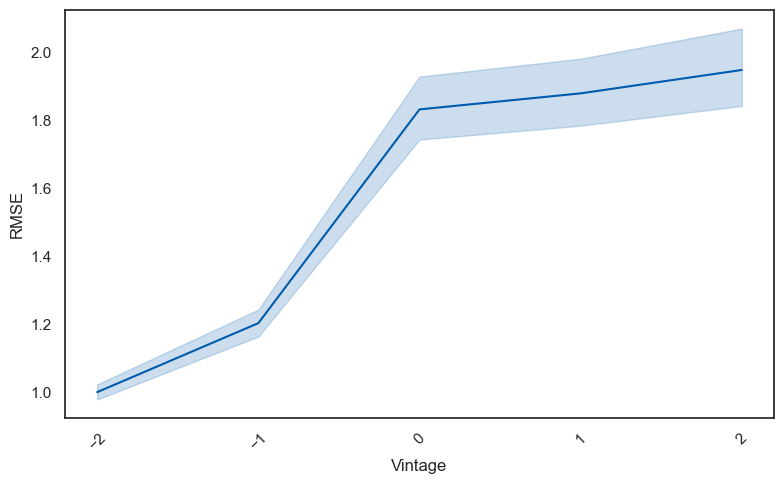

In [191]:
all_means = performance_table.groupby(performance_table.index)['RMSE'].mean()


fig, axes = plt.subplots(1, 1, figsize=(8, 5))  # adjust figsize as you want
# If axes is a single AxesSubplot (not an array), make it a list for consistency
axes = [axes]

# Plot
sns.lineplot(data=performance_table, x='Vintage', y='RMSE', ax=axes[0], color=idb_blue)

axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
axes[0].set_title("")
axes[0].tick_params(axis='x', rotation=45)
plt.tight_layout()

# Save figure:
plt.savefig(f'{PATH_OUTPUT}/Figure Vintage.png')
plt.show()

## Boxplot by publication lag

c:\Users\guerr\anaconda3\envs\est\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


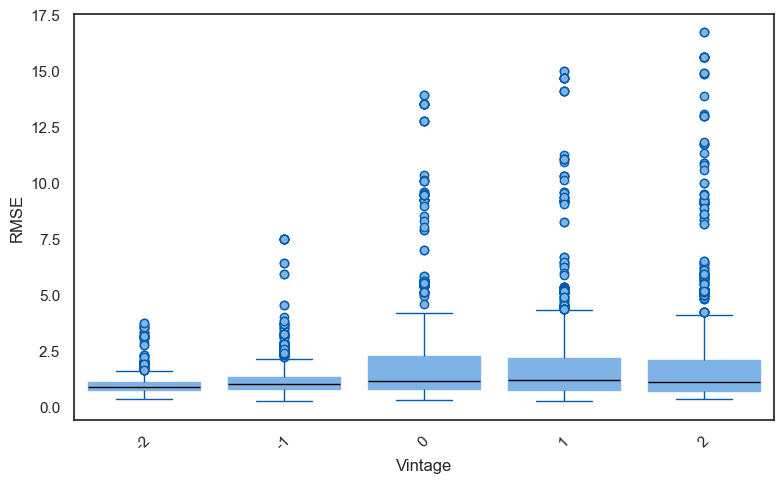

In [192]:
df = performance_table.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

# If you want a specific order, define it here; otherwise seaborn will infer it.
# order = sorted(df['Publication lag'].unique())
order = None

sns.boxplot(
    data=df,
    x='Vintage',
    y='RMSE',
    order=order,
    ax=ax,
    boxprops=dict(color=idb_light_blue),
    whiskerprops=dict(color=idb_blue),
    capprops=dict(color=idb_blue),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor=idb_light_blue, markeredgecolor=idb_blue,
                    marker='o', markersize=6)
)

ax.set_title("")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

c:\Users\guerr\anaconda3\envs\est\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


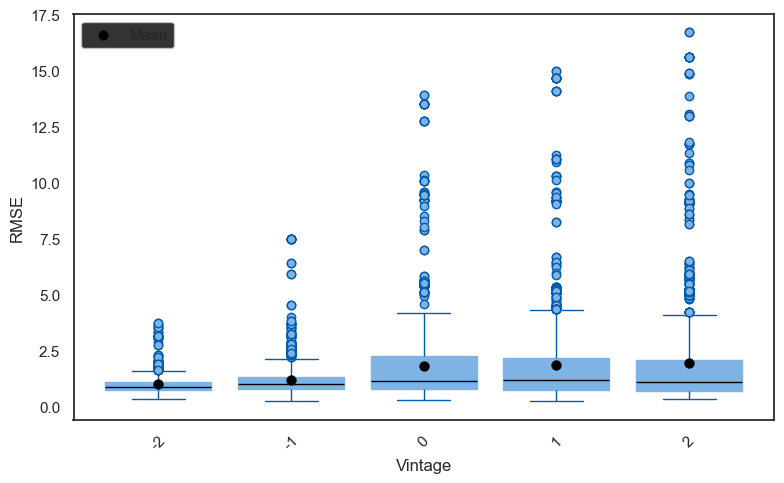

In [193]:
df = performance_table.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

# If you want a specific order, define it here; otherwise seaborn will infer it.
# order = sorted(df['Publication lag'].unique())
order = None

sns.boxplot(
    data=df,
    x='Vintage',
    y='RMSE',
    order=order,
    ax=ax,
    boxprops=dict(color=idb_light_blue),
    whiskerprops=dict(color=idb_blue),
    capprops=dict(color=idb_blue),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor=idb_light_blue, markeredgecolor=idb_blue,
                    marker='o', markersize=6)
)

# Get the actual category order used on the axis (this is key)
cats = [t.get_text() for t in ax.get_xticklabels()]

# Means computed in the same category space as the plot
means = df.groupby('Vintage', dropna=False)['RMSE'].mean()

# Map tick labels -> x positions
xpos = np.arange(len(cats))

# Overlay means (match tick labels carefully)
ymeans = []
for c in cats:
    # Try direct label
    if c in means.index:
        ymeans.append(means.loc[c])
        continue
    # Try numeric label -> numeric index match (common when lag is int/float)
    try:
        cnum = float(c)
        hit = None
        for idx in means.index:
            try:
                if float(idx) == cnum:
                    hit = means.loc[idx]
                    break
            except Exception:
                pass
        ymeans.append(hit)
    except Exception:
        ymeans.append(None)

# Plot only the ones we found
mask = [v is not None and np.isfinite(v) for v in ymeans]
ax.scatter(
    xpos[mask],
    np.array(ymeans, dtype=float)[mask],
    color='black',
    marker='o',
    s=50,
    zorder=10,
    edgecolor='k',
    linewidth=0.4,
    label='Mean'
)

# Clean legend (only "Mean" once)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

ax.set_title("")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Histogram: distribution of errors

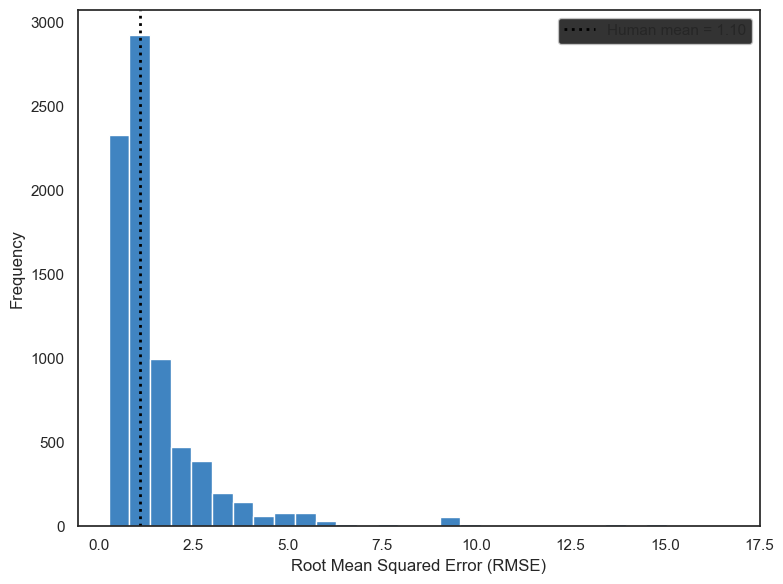

In [194]:
human_mean = performance_table[performance_table['spec']=='human1']['RMSE'].mean()

plt.figure(figsize=(8, 6))

# Plot with Seaborn, no edge lines
sns.histplot(performance_table['RMSE'], bins=30, kde=False, color=idb_blue, edgecolor=None)

# Median line
plt.axvline(human_mean, color='black', linestyle=':', linewidth=2, label=f'Human mean = {human_mean:.2f}')

plt.title("")
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

**Filter out extreme outliers using the vintage mean**

In [195]:
spec_rmse_mean = pd.DataFrame(performance_table.groupby('Vintage')['RMSE'].median())
spec_rmse_mean = spec_rmse_mean.rename(columns={'RMSE': 'threshold'})
spec_rmse_mean

,threshold
Vintage,
-2,0.895657
-1,1.021723
0,1.150316
1,1.180562
2,1.126067


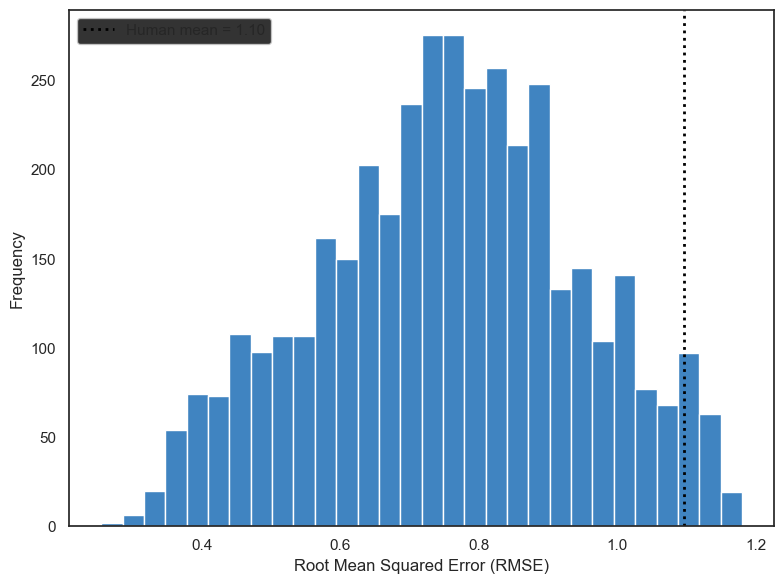

In [196]:
performance_table = performance_table.merge(spec_rmse_mean, on='Vintage', how='left')

# ++++++++++++++++++++++++++++++++++++++++++++++++++++
# ++++++++++++++++++++++++++++++++++++++++++++++++++++
filtered = performance_table[performance_table['RMSE'] < performance_table['threshold']]
# ++++++++++++++++++++++++++++++++++++++++++++++++++++
# ++++++++++++++++++++++++++++++++++++++++++++++++++++


human_mean = performance_table[performance_table['spec']=='human1']['RMSE'].mean()

plt.figure(figsize=(8, 6))

# Plot with Seaborn, no edge lines
sns.histplot(filtered['RMSE'], bins=30, kde=False, color=idb_blue, edgecolor=None)

# Median line
plt.axvline(human_mean, color='black', linestyle=':', linewidth=2, label=f'Human mean = {human_mean:.2f}')

plt.title("")
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Histogram conditional on publication lag

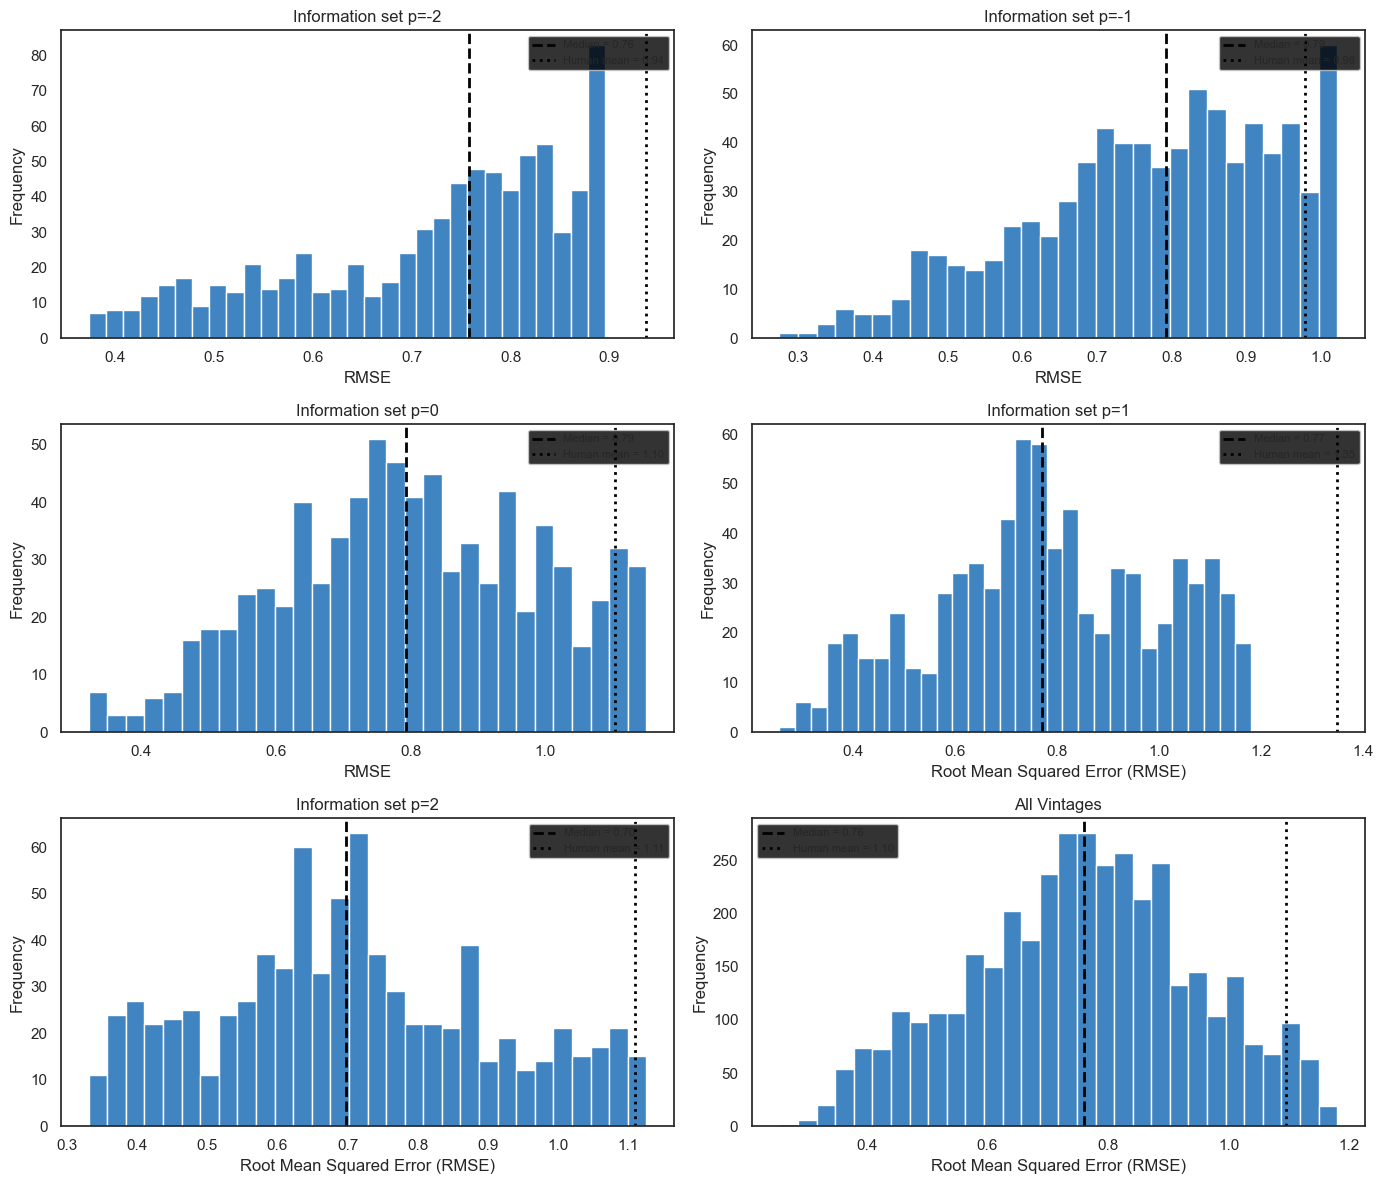

In [197]:
human_means = (
    performance_table[performance_table['spec'] == 'human1']
    .groupby('Vintage')
    .mean(numeric_only=True)
)

# Mapping of vintages
lags = {
    -2: 'two_back',
    -1: 'one_back',
     0: 'zero_back',
     1: 'one_ahead',
     2: 'two_ahead'
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12), sharex=False, sharey=False)
axes = axes.flatten()

# ------------------------------------------------
# Loop over each vintage and plot histogram
for i, (V, N) in enumerate(lags.items()):
    ax = axes[i]

    # Filter data for this vintage
    subset = filtered[filtered.index == V]

    # Histogram
    sns.histplot(subset['RMSE'], bins=30, kde=False, color=idb_blue, edgecolor=None, ax=ax)

    # Median line
    rmse_median = subset['RMSE'].median()
    ax.axvline(rmse_median, color='black', linestyle='dashed', linewidth=2, label=f'Median = {rmse_median:.2f}')

    # Human benchmark
    human_mean = human_means[human_means.index==V]['RMSE'].mean()
    ax.axvline(human_mean, color='black', linestyle=':', linewidth=2, label=f'Human mean = {human_mean:.2f}')

    # Titles
    ax.set_title(f'Information set p={V}', fontsize=12)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8, loc='upper right')

# ------------------------------------------------
# Last panel: pooled distribution
ax = axes[-1]
sns.histplot(filtered['RMSE'], bins=30, kde=False, color=idb_blue, edgecolor=None, ax=ax)

rmse_median = filtered['RMSE'].median()
ax.axvline(rmse_median, color='black', linestyle='dashed', linewidth=2, label=f'Median = {rmse_median:.2f}')

human_mean = performance_table[performance_table['spec'] == 'human1']['RMSE'].mean()
ax.axvline(human_mean, color='black', linestyle=':', linewidth=2, label=f'Human mean = {human_mean:.2f}')

ax.set_title('All Vintages', fontsize=12)
ax.set_ylabel('Frequency')
ax.legend(fontsize=8, loc='upper left')

# ------------------------------------------------
# X-labels on bottom row
for ax in axes[-3:]:
    ax.set_xlabel("Root Mean Squared Error (RMSE)")

plt.tight_layout()
plt.show()

## Boxplot (outliers management)

c:\Users\guerr\anaconda3\envs\est\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


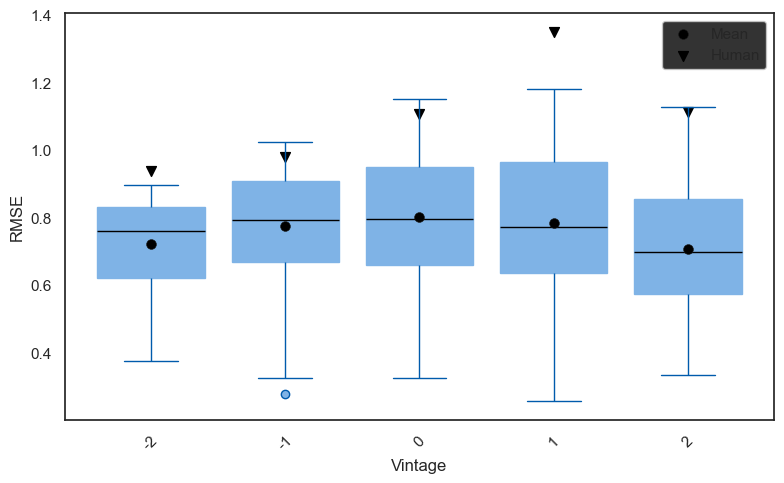

In [198]:
# First we define reference points
human_p = performance_table[performance_table['spec']=='human1']
human_p = human_p.groupby(human_p.index)['RMSE'].mean()
all_means = filtered.groupby(filtered.index)['RMSE'].mean()


fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=filtered.reset_index(),
    x='Vintage',
    y='RMSE',
    ax=ax,
    boxprops=dict(color=idb_light_blue),
    whiskerprops=dict(color=idb_blue),
    capprops=dict(color=idb_blue),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor=idb_light_blue, markeredgecolor=idb_blue, marker='o', markersize=6)
)

# Ensure the figure is rendered so tick labels are available
fig.canvas.draw()   # <- important

xticks = ax.get_xticks()
xtlabels = [t.get_text() for t in ax.get_xticklabels()]

# compute means (keep original dtype)
all_means = filtered.reset_index().groupby('Vintage')['RMSE'].mean()

def find_mean_for_label(lbl):
    # direct match
    if lbl in all_means.index:
        return all_means.loc[lbl]
    # try numeric match
    try:
        lbl_num = float(lbl)
        for idx in all_means.index:
            try:
                if float(idx) == lbl_num:
                    return all_means.loc[idx]
            except Exception:
                continue
    except Exception:
        pass
    # fallback: match by string representation
    for idx in all_means.index:
        if str(idx) == lbl:
            return all_means.loc[idx]
    return None

# plot mean markers aligned to the xtick positions
for i, lbl in enumerate(xtlabels):
    m = find_mean_for_label(lbl)
    if m is not None:
        ax.scatter(xticks[i], m, color='black', marker='o', s=50, zorder=10,
                   label='Mean' if i == 0 else "", edgecolor='k', linewidth=0.4)

# overlay human points: match similarly
for i, vintage in enumerate(human_p.index):
    # try to find which xtick corresponds
    for j, lbl in enumerate(xtlabels):
        try:
            if str(vintage) == lbl or float(vintage) == float(lbl):
                ax.scatter(xticks[j], human_p[vintage], color='black', marker='v', s=50,
                           label='Human' if i == 0 else "")
                break
        except Exception:
            if str(vintage) == lbl:
                ax.scatter(xticks[j], human_p[vintage], color='black', marker='v', s=50,
                           label='Human' if i == 0 else "")
                break

# clean legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys())

ax.set_title("")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


# Nowcast outputs:

## Results/RMSE merge

Filter out results from under-performing models

In [199]:
# -----------------------------------------------
# Reshape results to long format
df = results_table.reset_index().melt(
    id_vars=["date", 'spec', 'estimator'],
    value_vars=["two_back", "one_back", "zero_back", "one_ahead", "two_ahead"],
    var_name="horizon",
    value_name="value"
)

# Make Vintage column based on horizon -2, -1, 0, 1, 2
df['Vintage'] = df['horizon'].map({
    'two_back': -2,
    'one_back': -1,
    'zero_back': 0,
    'one_ahead': 1,
    'two_ahead': 2
})
df

,date,spec,estimator,horizon,value,Vintage
0,2022-06-01,lars35,OLS,two_back,0.260435,-2
1,2022-09-01,lars35,OLS,two_back,0.296594,-2
2,2022-12-01,lars35,OLS,two_back,0.412448,-2
3,2023-03-01,lars35,OLS,two_back,0.663927,-2
4,2023-06-01,lars35,OLS,two_back,0.657635,-2
...,...,...,...,...,...,...
555,2022-12-01,human1,LSTM,two_ahead,0.271022,2
556,2023-03-01,human1,LSTM,two_ahead,0.165676,2
557,2023-06-01,human1,LSTM,two_ahead,-0.201639,2
558,2023-09-01,human1,LSTM,two_ahead,-0.216906,2


In [200]:
p = performance_table.reset_index()
results_w = (
    df  # safe even if index is unnamed
    .rename(columns=str.strip)
    .merge(
        p.rename(columns=str.strip)[['Vintage','spec','estimator','RMSE']],
        on=['Vintage','spec','estimator'],
        how='left'
    )
)

In [201]:
mean_rmse = results_w.groupby('Vintage')['RMSE'].mean()

# Keep rows with RMSE <= Vintage-specific mean
filtered = results_w[
    results_w['RMSE'] <= results_w['Vintage'].map(mean_rmse)
]
filtered

,date,spec,estimator,horizon,value,Vintage,RMSE
0,2022-06-01,lars35,OLS,two_back,0.260435,-2,0.992348
1,2022-09-01,lars35,OLS,two_back,0.296594,-2,0.992348
2,2022-12-01,lars35,OLS,two_back,0.412448,-2,0.992348
3,2023-03-01,lars35,OLS,two_back,0.663927,-2,0.992348
4,2023-06-01,lars35,OLS,two_back,0.657635,-2,0.992348
...,...,...,...,...,...,...,...
555,2022-12-01,human1,LSTM,two_ahead,0.271022,2,0.705492
556,2023-03-01,human1,LSTM,two_ahead,0.165676,2,0.705492
557,2023-06-01,human1,LSTM,two_ahead,-0.201639,2,0.705492
558,2023-09-01,human1,LSTM,two_ahead,-0.216906,2,0.705492


## Ridge plot

In [202]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = filtered[['date', 'horizon', 'Vintage', 'value']]
observed = pd.DataFrame(results_table['actuals'].groupby(results_table.index).mean())
actuals_dict = observed['actuals'].to_dict()
df

,date,horizon,Vintage,value
0,2022-06-01,two_back,-2,0.260435
1,2022-09-01,two_back,-2,0.296594
2,2022-12-01,two_back,-2,0.412448
3,2023-03-01,two_back,-2,0.663927
4,2023-06-01,two_back,-2,0.657635
...,...,...,...,...
555,2022-12-01,two_ahead,2,0.271022
556,2023-03-01,two_ahead,2,0.165676
557,2023-06-01,two_ahead,2,-0.201639
558,2023-09-01,two_ahead,2,-0.216906


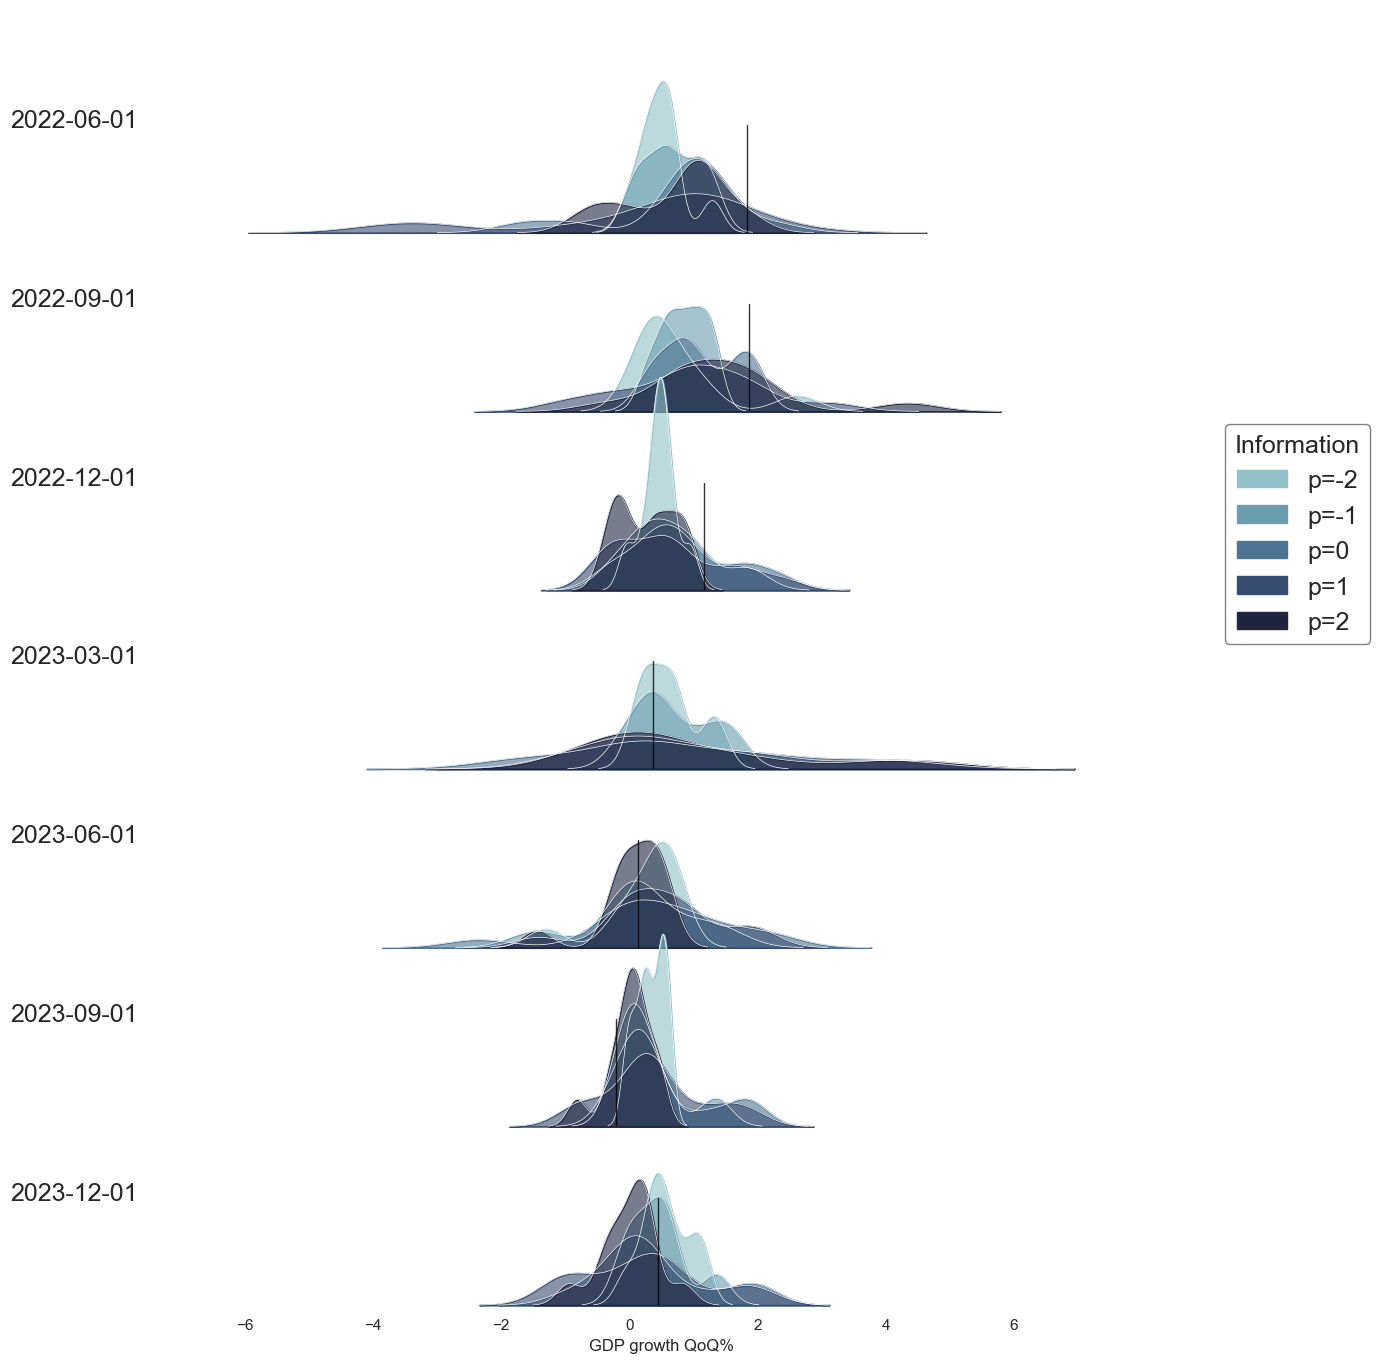

In [203]:
# Mock data to make the code runnable
dates = df["date"].unique()
horizons = ["two_back", "one_back", "zero_back", "one_ahead", "two_ahead"]
data = []
for date in dates:
    for horizon in horizons:
        # Create different distribution shapes to make the plot more interesting
        values = df[(df['date']==date) & (df['horizon']==horizon)].value
        data.extend([(date, horizon, v) for v in values])

df = pd.DataFrame(data, columns=["date", "horizon", "value"])

horizon_labels = {
    "two_back": "p=-2",
    "one_back": "p=-1",
    "zero_back": "p=0",
    "one_ahead": "p=1",
    "two_ahead": "p=2"
}
df["horizon"] = df["horizon"].map(horizon_labels)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Generate a range of colors for the horizons
horizons_unique = df["horizon"].unique()
n_horizons = len(horizons_unique)
pal = sns.cubehelix_palette(n_horizons, rot=-.25, light=.7)

# The fix is to add sharey=False
g = sns.FacetGrid(
    df,  
    row="date",  
    hue="horizon",  
    aspect=5,  
    height=2,  
    palette=pal,
    sharey=True  # This is the key change
)

# KDE distributions
g.map(
    sns.kdeplot,  
    "value",  
    bw_adjust=0.7,  
    clip_on=False,  
    fill=True,  
    alpha=0.6,  
    linewidth=1.2,
    common_norm=True
)

# Contour lines
g.map(
    sns.kdeplot,  
    "value",  
    bw_adjust=0.7,  
    clip_on=False,  
    color="w",  
    lw=0.5
)

# Adjust spacing between ridges
g.fig.subplots_adjust(hspace=-0.2)

# Y-axis labels as dates, remove density scale
for ax, date in zip(g.axes.flat, df["date"].unique()):
    ax.set_ylabel(date.strftime("%Y-%m-%d"), rotation=0, labelpad=50, ha="right", va="center", fontsize=18)
    ax.set_yticks([])
    ax.axhline(y=0, color="gray", lw=0.6, ls="--", alpha=0.7)

# Add observed (example without results_table)
# Loop through the axes and sorted dates to plot the correct 'actual' value
sorted_dates = sorted(df["date"].unique())
for ax, date in zip(g.axes.flat, sorted_dates):
    actual_value = actuals_dict.get(date)
    if actual_value is not None:
        # Create a line with y-coordinates from 0.1 to 0.9 of the axes height,
        # but with the x-coordinate in data units.
        line = plt.Line2D(
            [actual_value, actual_value], # x-coordinates in data units
            [0, 0.9],                   # y-coordinates in axes units
            transform=ax.transData,       # This is the correct transform object
            color='black', linestyle='-', lw=1, alpha=0.8
        )
        # Add the line to the current axes.
        ax.add_line(line)
     
# Cleanup axes
g.set(xlabel="GDP growth QoQ%")
g.set_titles("")
g.despine(bottom=True, left=True)

# Custom white legend
palette_dict = dict(zip(horizons_unique, pal))
handles = [mpatches.Patch(color=palette_dict[h], label=h) for h in horizons_unique]
plt.legend(
    handles=handles,  
    title="Information",  
    title_fontsize=18,  
    fontsize=18,  
    bbox_to_anchor=(1.2, 4),  
    loc="upper center",
    frameon=True,
    facecolor="white",
    edgecolor="gray",
    framealpha=1
)

# Save and show
plt.show()

## Weighted Nowcast

We will weight the nowcast by the inverse of the RMSE. Effectively, we will compute:

$$
\hat{v}
= \frac{\sum_{i=1}^{N} w_i \, v_i}{\sum_{i=1}^{N} w_i}
= \frac{\sum_{i=1}^{N} \dfrac{v_i}{\mathrm{RMSE}_i}}
       {\sum_{i=1}^{N} \dfrac{1}{\mathrm{RMSE}_i}}
$$

We can also estimate a weighted confidence interval using the same weights.

$$
\mathrm{SE}(\hat{v})
= \frac{1}{\sqrt{\sum_{i=1}^{N} w_i}}
= \left( \sum_{i=1}^{N} \frac{1}{\mathrm{RMSE}_i} \right)^{-1/2}
$$

$$
\hat{v} \pm 1.96 \cdot \mathrm{SE}(\hat{v})
$$



In [204]:
filtered = filtered.copy()
filtered['date'] = pd.to_datetime(filtered['date'])
filtered['weight'] = 1 / filtered['RMSE']
filtered

,date,spec,estimator,horizon,value,Vintage,RMSE,weight
0,2022-06-01,lars35,OLS,two_back,0.260435,-2,0.992348,1.007711
1,2022-09-01,lars35,OLS,two_back,0.296594,-2,0.992348,1.007711
2,2022-12-01,lars35,OLS,two_back,0.412448,-2,0.992348,1.007711
3,2023-03-01,lars35,OLS,two_back,0.663927,-2,0.992348,1.007711
4,2023-06-01,lars35,OLS,two_back,0.657635,-2,0.992348,1.007711
...,...,...,...,...,...,...,...,...
555,2022-12-01,human1,LSTM,two_ahead,0.271022,2,0.705492,1.417451
556,2023-03-01,human1,LSTM,two_ahead,0.165676,2,0.705492,1.417451
557,2023-06-01,human1,LSTM,two_ahead,-0.201639,2,0.705492,1.417451
558,2023-09-01,human1,LSTM,two_ahead,-0.216906,2,0.705492,1.417451


In [205]:
df = results_table[['actuals']]
df = df.groupby('date').mean()
df.index = pd.to_datetime(df.index)
df

,actuals
date,
2022-06-01,1.834934
2022-09-01,1.861167
2022-12-01,1.161478
2023-03-01,0.365621
2023-06-01,0.142751
2023-09-01,-0.206811
2023-12-01,0.447653


In [206]:
# ---------------------------------------------------
V = -2
N = "two_back"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')


df = df.merge(weighted, left_index=True, right_index=True, how='left')
df

,actuals,two_back
date,,
2022-06-01,1.834934,0.600711
2022-09-01,1.861167,0.831076
2022-12-01,1.161478,0.514612
2023-03-01,0.365621,0.659867
2023-06-01,0.142751,0.244418
2023-09-01,-0.206811,0.298475
2023-12-01,0.447653,0.526645


In [207]:
# ---------------------------------------------------
V = -1
N = "one_back"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')

df = df.merge(weighted, left_index=True, right_index=True, how='left')

# ---------------------------------------------------
V = 0
N = "zero_back"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')

df = df.merge(weighted, left_index=True, right_index=True, how='left')

# ---------------------------------------------------
V = 1
N = "one_ahead"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')

df = df.merge(weighted, left_index=True, right_index=True, how='left')

# ---------------------------------------------------
V = 2
N = "two_ahead"

d = filtered.loc[filtered['Vintage'] == V]
weighted = (
    (d['value'] * d['weight']).groupby(d['date']).sum()
    / d.groupby(d['date'])['weight'].sum()
).reset_index(name=N).set_index('date')

df = df.merge(weighted, left_index=True, right_index=True, how='left')

df

,actuals,two_back,one_back,zero_back,one_ahead,two_ahead
date,,,,,,
2022-06-01,1.834934,0.600711,0.728040,0.913044,0.685764,0.906044
2022-09-01,1.861167,0.831076,0.839644,1.082340,1.129012,1.383984
2022-12-01,1.161478,0.514612,0.638893,0.696455,0.585210,0.335493
2023-03-01,0.365621,0.659867,0.638623,0.487780,0.649361,0.730471
2023-06-01,0.142751,0.244418,0.136615,0.444286,0.451624,0.107074
2023-09-01,-0.206811,0.298475,0.225906,0.395838,0.407054,-0.002993
2023-12-01,0.447653,0.526645,0.378249,0.303686,0.263156,0.004322


Alternatively... a loop, from start:

In [208]:
horizons = {
    'two_back': -2,
    'one_back': -1,
    'zero_back': 0,
    'one_ahead': 1,
    'two_ahead': 2
}

filtered = filtered.copy()
filtered['date'] = pd.to_datetime(filtered['date'])
filtered['weight'] = 1 / filtered['RMSE']

df = results_table[['actuals']]
df = df.groupby('date').mean()
df.index = pd.to_datetime(df.index)
df

,actuals
date,
2022-06-01,1.834934
2022-09-01,1.861167
2022-12-01,1.161478
2023-03-01,0.365621
2023-06-01,0.142751
2023-09-01,-0.206811
2023-12-01,0.447653


In [209]:
horizons = {
    'two_back': -2,
    'one_back': -1,
    'zero_back': 0,
    'one_ahead': 1,
    'two_ahead': 2
}

for N, V in horizons.items():
    d = filtered.loc[filtered['Vintage'] == V]

    weighted = (
        (d['value'] * d['weight']).groupby(d['date']).sum()
        / d.groupby(d['date'])['weight'].sum()
    ).reset_index(name=N).set_index('date')

    df = df.merge(weighted, left_index=True, right_index=True, how='left')

df


,actuals,two_back,one_back,zero_back,one_ahead,two_ahead
date,,,,,,
2022-06-01,1.834934,0.600711,0.728040,0.913044,0.685764,0.906044
2022-09-01,1.861167,0.831076,0.839644,1.082340,1.129012,1.383984
2022-12-01,1.161478,0.514612,0.638893,0.696455,0.585210,0.335493
2023-03-01,0.365621,0.659867,0.638623,0.487780,0.649361,0.730471
2023-06-01,0.142751,0.244418,0.136615,0.444286,0.451624,0.107074
2023-09-01,-0.206811,0.298475,0.225906,0.395838,0.407054,-0.002993
2023-12-01,0.447653,0.526645,0.378249,0.303686,0.263156,0.004322


## Graph results

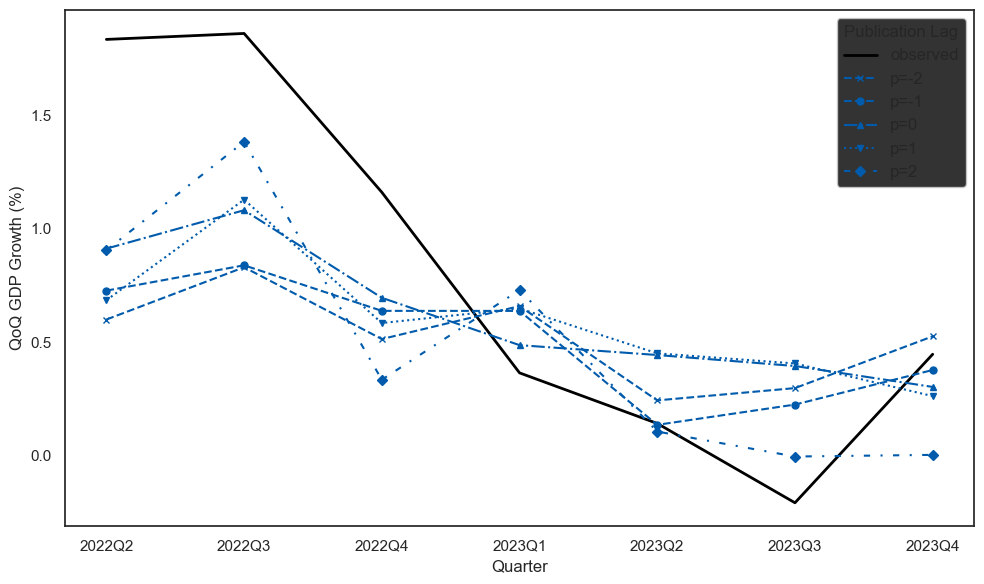

In [210]:
plot_df = df.rename(columns={
    'actuals': 'observed',
    'two_back': 'p=-2',
    'one_back': 'p=-1',
    'zero_back': 'p=0',
    'one_ahead': 'p=1',
    'two_ahead': 'p=2'
})
plot_df.index = pd.PeriodIndex(plot_df.index, freq='Q').astype(str)
fig, ax = plt.subplots(figsize=(10,6))

# Plot 'observed' as a black dashed line, no marker
plot_df['observed'].plot(
    ax=ax, color='black', linestyle='-', linewidth=2, label='observed'
)

# Define line styles and markers for other lines
line_styles = ['--', '--', '-.', ':', (0, (3, 5, 1, 5))]  # various dash styles
markers = ['x', 'o', '^', 'v', 'D']  # circle, square, triangle up/down, diamond

# Plot the rest with unique line styles and markers
for idx, col in enumerate(['p=-2', 'p=-1', 'p=0', 'p=1', 'p=2']):
    plot_df[col].plot(
        ax=ax,
        color=idb_blue,
        linestyle=line_styles[idx],
        marker=markers[idx],
        linewidth=1.5,
        markersize=5,
        label=col
    )

# Labels and grid
ax.set_title('')
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('QoQ GDP Growth (%)', fontsize=12)
ax.legend(title='Publication Lag', fontsize=12, title_fontsize=12)
plt.tight_layout()

plt.show()

## Weighted Nowcast with Confidence Intervals

In [211]:
df = results_table[['actuals']].groupby('date').mean()
df

,actuals
date,
2022-06-01,1.834934
2022-09-01,1.861167
2022-12-01,1.161478
2023-03-01,0.365621
2023-06-01,0.142751
2023-09-01,-0.206811
2023-12-01,0.447653


In [212]:
lags = {
    -2: 'two_back',
    -1: 'one_back',
     0: 'zero_back',
     1: 'one_ahead',
     2: 'two_ahead'
}

for V, N in lags.items():
    # Read and prepare results_table fresh in each loop
    New_Table = filtered.copy()
    d = New_Table.loc[New_Table['Vintage'] == V]

    g = d.groupby('date')

    meanN = (
        (d['value'] * d['weight']).groupby(d['date']).sum()
        / g['weight'].sum()
    ).rename(N)

    seN = (1 / np.sqrt(g['weight'].sum())).rename(f'se_{N}')

    weighted = pd.concat([meanN, seN], axis=1)

    # Compute 95% confidence interval bounds
    weighted[f'ci_lower_{N}'] = weighted[N] - 1.96 * weighted[f'se_{N}']
    weighted[f'ci_upper_{N}'] = weighted[N] + 1.96 * weighted[f'se_{N}']

    # Concatenate the new columns to the main df
    df = df.join(weighted[[N, f'se_{N}', f'ci_lower_{N}', f'ci_upper_{N}']])

df.index = pd.PeriodIndex(df.index, freq='Q').astype(str)
df

,actuals,two_back,se_two_back,ci_lower_two_back,ci_upper_two_back,one_back,se_one_back,ci_lower_one_back,ci_upper_one_back,zero_back,...,ci_lower_zero_back,ci_upper_zero_back,one_ahead,se_one_ahead,ci_lower_one_ahead,ci_upper_one_ahead,two_ahead,se_two_ahead,ci_lower_two_ahead,ci_upper_two_ahead
date,,,,,,,,,,,,,,,,,,,,,
2022Q2,1.834934,0.600711,0.298052,0.016529,1.184892,0.728040,0.336789,0.067933,1.388147,0.913044,...,0.367598,1.458490,0.685764,0.282586,0.131895,1.239633,0.906044,0.260506,0.395452,1.416636
2022Q3,1.861167,0.831076,0.298052,0.246894,1.415257,0.839644,0.336789,0.179537,1.499751,1.082340,...,0.536894,1.627786,1.129012,0.282586,0.575143,1.682881,1.383984,0.260506,0.873392,1.894576
2022Q4,1.161478,0.514612,0.298052,-0.069569,1.098794,0.638893,0.336789,-0.021214,1.299000,0.696455,...,0.151010,1.241901,0.585210,0.282586,0.031341,1.139079,0.335493,0.260506,-0.175100,0.846085
2023Q1,0.365621,0.659867,0.298052,0.075685,1.244048,0.638623,0.336789,-0.021484,1.298730,0.487780,...,-0.057666,1.033226,0.649361,0.282586,0.095492,1.203230,0.730471,0.260506,0.219879,1.241064
2023Q2,0.142751,0.244418,0.298052,-0.339764,0.828599,0.136615,0.336789,-0.523492,0.796722,0.444286,...,-0.101160,0.989732,0.451624,0.282586,-0.102245,1.005493,0.107074,0.260506,-0.403518,0.617666
2023Q3,-0.206811,0.298475,0.298052,-0.285706,0.882656,0.225906,0.336789,-0.434201,0.886013,0.395838,...,-0.149608,0.941284,0.407054,0.282586,-0.146815,0.960923,-0.002993,0.260506,-0.513585,0.507599
2023Q4,0.447653,0.526645,0.298052,-0.057536,1.110827,0.378249,0.336789,-0.281858,1.038357,0.303686,...,-0.241760,0.849132,0.263156,0.282586,-0.290713,0.817025,0.004322,0.260506,-0.506270,0.514914


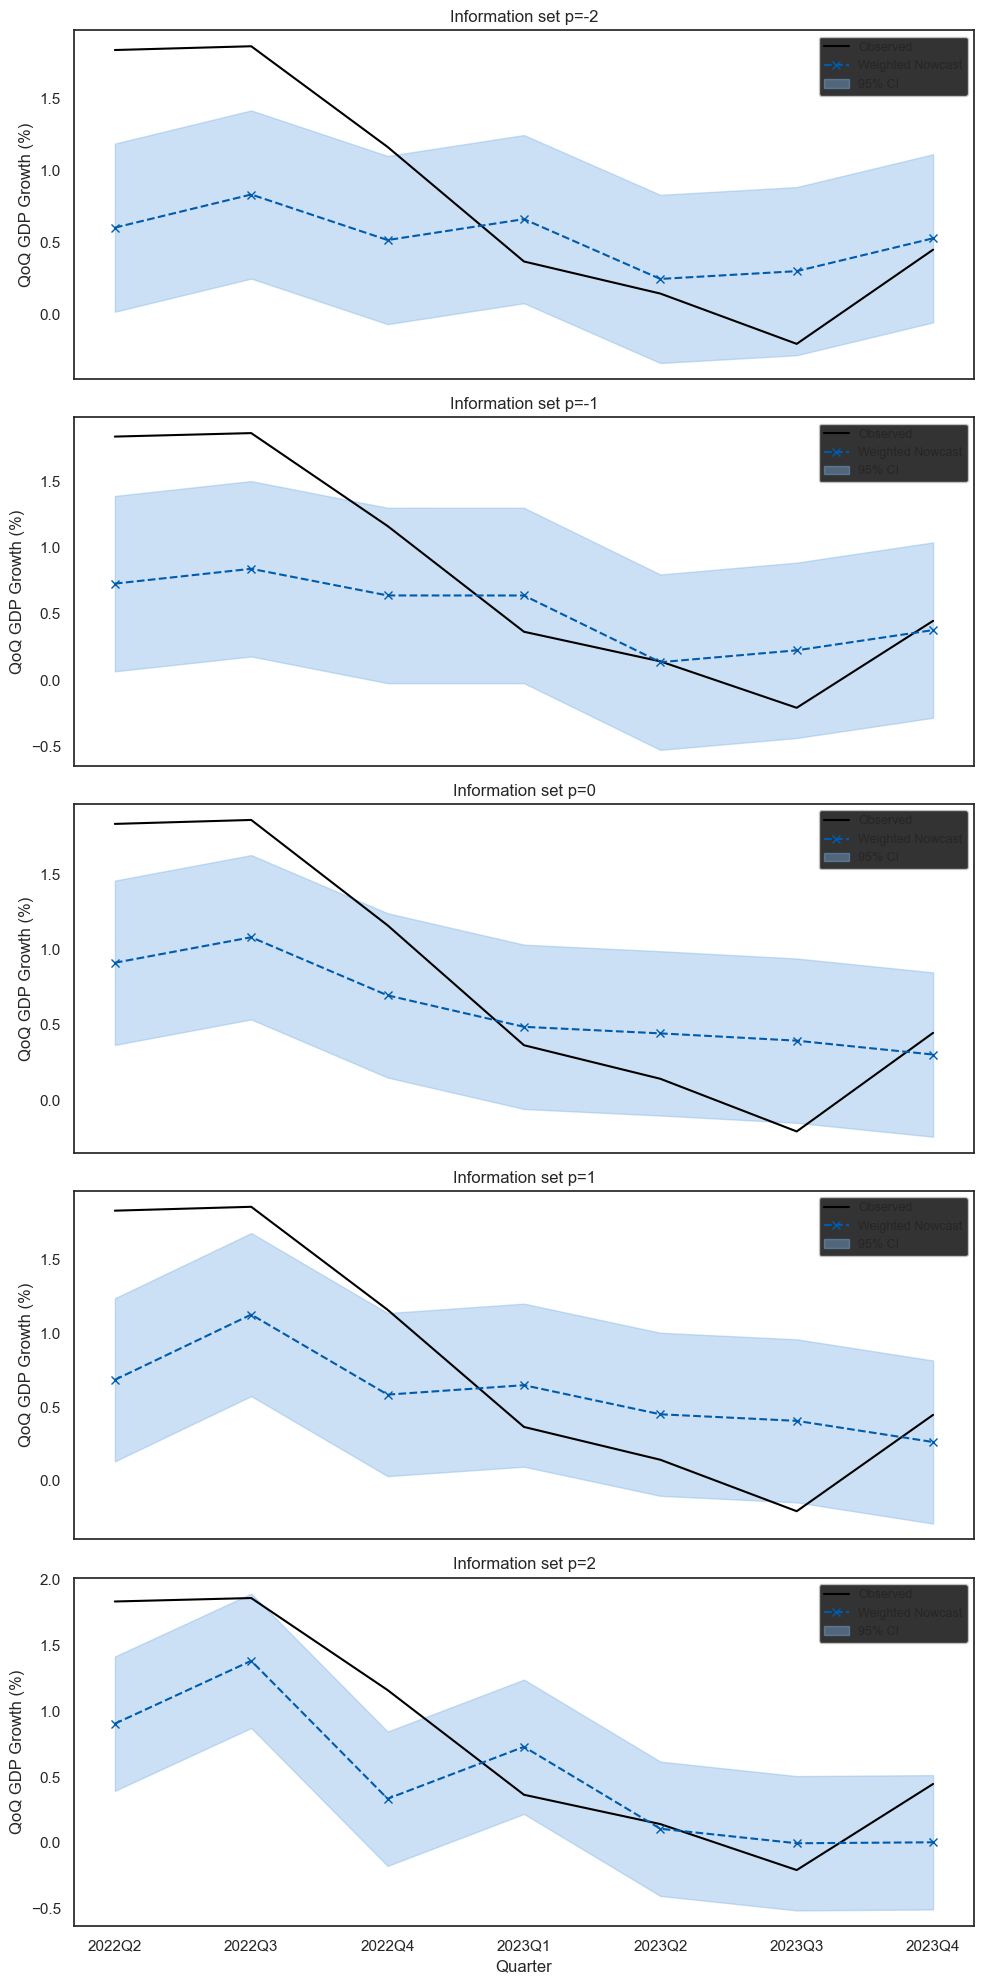

In [213]:
lags = {
    -2: 'two_back',
    -1: 'one_back',
     0: 'zero_back',
     1: 'one_ahead',
     2: 'two_ahead'
}

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20), sharex=True)

# ------------------------------------------------
# Loop over each vintage and plot
for ax, (V, N) in zip(axes, lags.items()):
    # Plot actuals
    ax.plot(df.index, df['actuals'], color='black', linestyle='-', label='Observed')
    
    # Plot nowcast for vintage N
    ax.plot(df.index, df[N], color=idb_blue, linestyle='--', marker='x', label=f'Weighted Nowcast')
    
    # Plot confidence interval as a shaded area
    ax.fill_between(
        df.index,
        df[f'ci_lower_{N}'],
        df[f'ci_upper_{N}'],
        color=idb_light_blue,
        alpha=0.4,
        label='95% CI'
    )
    
    # Titles and labels
    ax.set_title(f'Information set p={V}', fontsize=12)
    ax.set_ylabel('QoQ GDP Growth (%)')
    ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('Quarter')

plt.tight_layout()
plt.show()